# 04 — CLV and Revenue at Risk

This notebook uses transparent historical customer value plus a cohort-based 12-month projection. It avoids lifetime-value assumptions: the projection is only the next 12 months and is derived from observed cohort retention.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.append(str(ROOT / 'src'))

from retail_analytics.clv import build_customer_clv, clv_summary
from retail_analytics.dashboard import build_dashboard_html, write_aggregate_exports, write_dashboard
from retail_analytics.engine import build_connection

FIG_DIR = ROOT / 'reports' / 'figures'
OUTPUT_DIR = ROOT / 'outputs'
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

con = build_connection()
snapshot_date = con.sql('SELECT MAX(invoice_date) FROM transactions_clean').fetchone()[0]
snapshot_date


datetime.datetime(2011, 12, 9, 12, 50)

## Customer-level 12-month projection

For each customer, monthly value equals historical revenue divided by observed customer months. The retention multiplier comes from the average cohort survival curve and estimates expected active months over the next 12 months conditional on the customer age observed at the snapshot.

In [2]:
customer_segments = con.sql('''
    SELECT
        s.customer_id,
        b.first_order_date,
        b.last_order_date,
        b.n_orders,
        b.tenure_days,
        b.total_revenue,
        s.days_since_last_order,
        s.frequency,
        s.monetary,
        s.r_score,
        s.f_score,
        s.m_score,
        s.rfm_total,
        s.segment
    FROM rfm_segments s
    JOIN customer_base b USING (customer_id)
''').df()
cohort_retention = con.sql('SELECT * FROM cohort_retention').df()
customer_clv = build_customer_clv(customer_segments, cohort_retention, snapshot_date)
customer_clv.head()


,customer_id,first_order_date,last_order_date,n_orders,tenure_days,total_revenue,days_since_last_order,frequency,monetary,r_score,...,segment,age_months,observed_months,historical_value,monthly_value,retention_multiplier_12m,projected_12m_value,transparent_clv_12m,is_slipping_high_value,revenue_at_stake
1718,15749,2011-01-11 12:55:00,2011-04-18 13:20:00,3,97,44534.30,235,3,44534.30,2,...,At Risk,11,4.186858,44534.30,10636.686660,11.9567,127179.67,171713.97,True,127179.67
1506,14028,2010-06-07 12:02:00,2010-06-07 13:33:00,3,0,10396.50,550,3,10396.50,1,...,At Risk,18,1.000000,10396.50,10396.500000,12.0000,124758.00,135154.50,True,124758.00
1705,13902,2009-12-15 10:02:00,2010-03-17 13:09:00,5,92,34023.26,632,5,34023.26,1,...,Can't Lose,24,4.022587,34023.26,8458.053915,12.0000,101496.65,135519.91,True,101496.65
1733,16754,2010-03-08 11:32:00,2010-12-02 17:38:00,29,269,67502.47,372,29,67502.47,2,...,Can't Lose,21,9.837782,67502.47,6861.553515,12.0000,82338.64,149841.11,True,82338.64
1737,12346,2010-03-02 13:08:00,2011-01-18 10:01:00,3,322,77352.96,325,3,77352.96,2,...,At Risk,21,11.579055,77352.96,6680.420557,12.0000,80165.05,157518.01,True,80165.05


In [3]:
targeting = customer_clv.loc[
    customer_clv['is_slipping_high_value'],
    [
        'customer_id', 'segment', 'last_order_date', 'days_since_last_order', 'n_orders',
        'historical_value', 'projected_12m_value', 'transparent_clv_12m', 'revenue_at_stake',
    ],
].copy()
targeting.to_csv(OUTPUT_DIR / 'revenue_at_risk_targeting_list.csv', index=False)
summary = clv_summary(customer_clv)
summary


{'target_customers': 335,
 'revenue_at_stake': 1999052.45,
 'historical_value': 1296189.11,
 'avg_days_since_last_order': 353.0}

## Revenue at stake

The target list is deliberately narrow: high monetary-score customers in Can't Lose or At Risk segments. These customers have already proven value, but their recency score says they are slipping.

In [4]:
risk_by_segment = (
    customer_clv[customer_clv['is_slipping_high_value']]
    .groupby('segment', as_index=False)
    .agg(
        target_customers=('customer_id', 'count'),
        historical_value=('historical_value', 'sum'),
        projected_12m_value=('projected_12m_value', 'sum'),
        revenue_at_stake=('revenue_at_stake', 'sum'),
        avg_days_since_last_order=('days_since_last_order', 'mean'),
    )
    .round(2)
    .sort_values('revenue_at_stake', ascending=False)
)
risk_by_segment


,segment,target_customers,historical_value,projected_12m_value,revenue_at_stake,avg_days_since_last_order
1,Can't Lose,232,966514.03,1246713.51,1246713.51,340.17
0,At Risk,103,329675.08,752338.94,752338.94,382.00


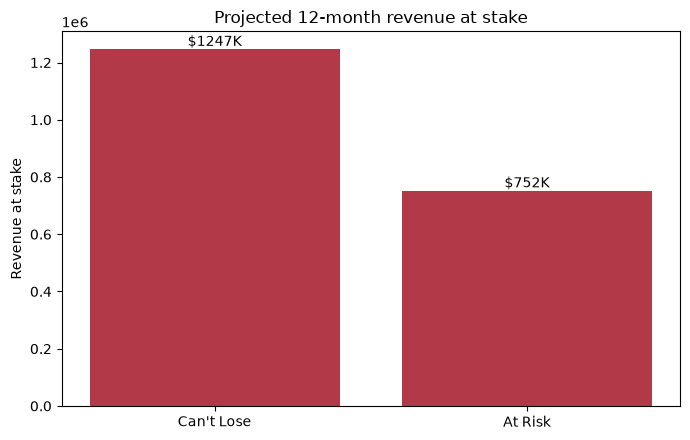

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(risk_by_segment['segment'], risk_by_segment['revenue_at_stake'], color='#B23A48')
ax.set_title('Projected 12-month revenue at stake')
ax.set_ylabel('Revenue at stake')
for i, value in enumerate(risk_by_segment['revenue_at_stake']):
    ax.text(i, value, f'${value/1000:.0f}K', ha='center', va='bottom')
fig.tight_layout()
fig.savefig(FIG_DIR / 'revenue_at_risk.png', dpi=160)
plt.show()


## Aggregate exports and dashboard

Only aggregate data is sent to Tableau-ready files and the HTML dashboard. The customer-level targeting CSV stays in `outputs/` for CRM activation.

In [6]:
segment_summary = con.sql('SELECT * FROM rfm_segment_summary ORDER BY revenue DESC').df()
revenue_concentration = con.sql('''
    SELECT cumulative_customer_pct, cumulative_revenue_pct
    FROM revenue_concentration
    ORDER BY revenue_rank
''').df()
revenue_summary = con.sql('SELECT * FROM revenue_concentration_summary').df()
clean_kpis = con.sql('''
    SELECT COUNT(DISTINCT customer_id) AS n_customers, ROUND(SUM(revenue), 2) AS total_revenue
    FROM transactions_clean
''').df().iloc[0].to_dict()

kpis = {
    **summary,
    **clean_kpis,
    'top_10_revenue_share': float(
        revenue_summary.loc[revenue_summary['top_pct_of_customers'] == 10, 'revenue_share_pct'].iloc[0]
    ),
}
write_aggregate_exports(
    segment_summary=segment_summary,
    cohort_retention=cohort_retention,
    revenue_concentration=revenue_concentration,
    revenue_at_risk_by_segment=risk_by_segment,
    kpis=kpis,
)
html = build_dashboard_html(
    kpis=kpis,
    segment_summary=segment_summary,
    cohort_retention=cohort_retention,
    revenue_concentration=revenue_concentration,
    revenue_at_risk_by_segment=risk_by_segment,
)
write_dashboard(html)
kpis


{'target_customers': 335,
 'revenue_at_stake': 1999052.45,
 'historical_value': 1296189.11,
 'avg_days_since_last_order': 353.0,
 'n_customers': 5852.0,
 'total_revenue': 17434464.73,
 'top_10_revenue_share': 63.86}

In [7]:
print(
    f"Target {summary['target_customers']:,} high-value slipping customers; "
    f"projected 12-month revenue at stake is ${summary['revenue_at_stake']:,.0f}."
)
print(f"Top 10% of customers drive {kpis['top_10_revenue_share']:.1f}% of clean revenue.")
print(f"Targeting list written to {OUTPUT_DIR / 'revenue_at_risk_targeting_list.csv'}")


Target 335 high-value slipping customers; projected 12-month revenue at stake is $1,999,052.
Top 10% of customers drive 63.9% of clean revenue.
Targeting list written to /Users/kyle_z/Documents/UMN/portfolio/retail-customer-analytics/outputs/revenue_at_risk_targeting_list.csv
